# Assignment 4 — CIFAR-10 ConvNet

**DATAX504** · Due end of Week 8

Build on **Chapter 8** (ConvNets, augmentation) and ideas from **Chapters 9–10** (interpretation). You design the stack; the goal is a working pipeline you can explain, not a copy of a tutorial.

## Tasks
1. Load CIFAR-10, normalise, create a train / validation split
2. Build a **data augmentation** pipeline used during training
3. Train a **ConvNet** that reaches **>65%** test accuracy
4. Visualise at least one filter / feature (layer weights or activation-based)
5. Brief interpretation of what that filter responds to (Moodle `a4_interpretation`)

## Moodle fields
`a4_repo`, `a4_test_acc`, `a4_filter_layer`, `a4_interpretation`

## AI disclosure (required)
Fill the table in the next cell before you submit.


## AI disclosure

| Field | Your answer |
|-------|-------------|
| Tool / model | OpenCode + Claude Sonnet 5 (Anthropic) |
| Used for | Explaining Keras/TensorFlow concepts, debugging errors, discussing architecture/callback choices, and designing filter-visualisation experiments |
| Verified how | Ran all code myself, checked outputs at each step, cross-checked against course textbook chapters 8-10, and tested filter hypotheses against real images |
| Not used for | Architecture/training decisions or writing the interpretation without understanding it myself |



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras import layers
import tensorflow as tf
from google.colab import drive
drive.mount('/content/drive')
import os
os.makedirs("/content/drive/MyDrive/DATAX504", exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Load & prepare CIFAR-10

Hints:
- `keras.datasets.cifar10.load_data()`
- cast pixels to float and scale to `[0, 1]` (or another range you document)
- flatten label shape if needed (`y.ravel()`)
- hold out a validation slice from the training set (e.g. last 5_000 or 10_000)


In [ ]:
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]
#class names to match the labels 0-9

#download train/test from cifar10
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

#cast pixels to float and scale to [0, 1]
#images stored as uint8 255 raw we divide by 255 to get them in the range 0-1 for scaling
print("train before:",x_train.dtype, x_train.min(), x_train.max())
x_train = x_train.astype("float32") / 255
print("train after",x_train.dtype, x_train.min(), x_train.max())

print("test before",x_test.dtype, x_test.min(), x_test.max())
x_test = x_test.astype("float32") / 255
print("test after",x_test.dtype, x_test.min(), x_test.max())

# Use ravel to get this ready for sparse categorical cross entropy - one integer label for the y labels
print("train shape before:", getattr(x_train, "shape", None), getattr(y_train, "shape", None))
print("test shape before:  ", getattr(x_test, "shape", None), getattr(y_test, "shape", None))
y_train = y_train.ravel()
y_test = y_test.ravel()

# validation split from training data
x_val = x_train[-5000:] #last 5000 images
y_val = y_train[-5000:] #last 5000 images
x_train = x_train[:-5000] #remainder for train 45,000
y_train = y_train[:-5000] #remainder for train 45,000

print("train:", getattr(x_train, "shape", None), getattr(y_train, "shape", None))
print("val:  ", getattr(x_val, "shape", None), getattr(y_val, "shape", None))
print("test: ", getattr(x_test, "shape", None), getattr(y_test, "shape", None))
print(y_train[0])
print(class_names[y_train[0]])


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step
train before: uint8 0 255
train after float32 0.0 1.0
test before uint8 0 255
test after float32 0.0 1.0
train shape before: (50000, 32, 32, 3) (50000, 1)
test shape before:   (10000, 32, 32, 3) (10000, 1)
train: (45000, 32, 32, 3) (45000,)
val:   (5000, 32, 32, 3) (5000,)
test:  (10000, 32, 32, 3) (10000,)
6
frog


## 2. Data augmentation

Build a small `keras.Sequential` of image layers (e.g. flip / rotation / zoom).
Apply it **inside** the model (or as a preprocessing layer) so training sees augmented batches.

Preview a few transforms on one training image to check it works.


(1, 32, 32, 3)


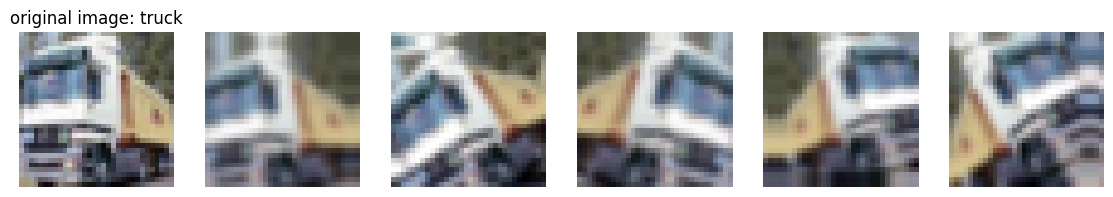

In [ ]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),#does not make sense with these images to do vertical
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        layers.RandomTranslation(0.1,0.1), #height and width factor
        layers.RandomContrast(0.1) #helps with lighting variations
    ],
    name="augmentation",
)

# TODO: preview — take one image from x_train, run it through data_augmentation a few times, plot
sample = x_train[1:2]
print(sample.shape)
fig, axes = plt.subplots(1, 6, figsize=(14, 3))
# original image first
axes[0].imshow(sample[0])
axes[0].set_title(f"original image: {class_names[y_train[1]]}")
axes[0].axis("off")

for i in range(5):
    output = data_augmentation(sample, training=True) #send sample data of batchsize 1 in for training
    axes[i+1].imshow(output[0])
    axes[i+1].axis("off")
plt.show()


## 3. ConvNet model

Requirements:
- Input shape `(32, 32, 3)`
- Include your augmentation as the first stage of the graph (training only behaviour is fine)
- At least two `Conv2D` + pooling stages, then a dense classifier for 10 classes
- Name at least one early conv layer (you will need the name for visualisation)

Compile with a suitable loss for integer class labels (or one-hot — be consistent).

### Experimental process (ablation)

Built the model incrementally, testing one change at a time against validation accuracy before adding the next (architecture and training settings both included):

| Architecture | Key changes | Best val accuracy |
|---|---|---|
| 3-stage (32→64→128) | batch 64, 30 epochs | 73.3% |
| 3-stage (32→64→128) | batch 128, 50 epochs, checkpointing | 78.2% |
| 4-stage (32→64→128→256) | + LR reduction, early stopping | 80.9% |
| 6-stage (32→32→64→64→128→128) | + dropout, same-padding | 83.5% val |

Batch size was tested and ruled out as the cause of validation noise; dropout was added only once a train/val gap appeared with the deeper model.

In [ ]:
inputs = keras.Input(shape=(32, 32, 3))
x = data_augmentation(inputs)

# TODO: Conv / pool / (optional BatchNorm, Dropout) stack
# Tip: name an early conv, e.g. name="conv2d_1"
print(x.shape)
x = layers.Conv2D(32, 3, use_bias=False,padding="same",name="conv2d_1")(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
print(x.shape)
x = layers.Conv2D(32, 3, use_bias=False,padding="same",name="conv2d_2")(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
x = layers.MaxPooling2D(2)(x)
print(x.shape)
x = layers.Conv2D(64, 3, use_bias=False,padding="same",name="conv2d_3")(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
print(x.shape)
x = layers.Conv2D(64, 3, use_bias=False,padding="same",name="conv2d_4")(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
x = layers.MaxPooling2D(2)(x)
print(x.shape)
x = layers.Conv2D(128, 3, use_bias=False,padding="same",name="conv2d_5")(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
print(x.shape)
x = layers.Conv2D(128, 3, use_bias=False,padding="same",name="conv2d_6")(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
print(x.shape)

# TODO: classifier head → 10-class output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(10, activation="softmax")(x)
model = keras.Model(inputs, outputs)
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",  #as we are using integer y labels one label per class
    metrics=["accuracy"],
)
model.summary()

print("Model ready:", model is not None)


(None, 32, 32, 3)
(None, 32, 32, 32)
(None, 16, 16, 32)
(None, 16, 16, 64)
(None, 8, 8, 64)
(None, 8, 8, 128)
(None, 8, 8, 128)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 128)      │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 8, 8, 128)      │             

 Total params: 289,642 (1.10 MB)

 Trainable params: 288,746 (1.10 MB)

 Non-trainable params: 896 (3.50 KB)

Model ready: True


## 4. Train & evaluate

Fit with `validation_data`. Aim for **>65%** test accuracy (Moodle wants the percentage).
Plot train vs val accuracy if useful for your write-up.


Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.3670 - loss: 1.7335
Epoch 1: val_accuracy improved from None to 0.33280, saving model to /content/drive/MyDrive/DATAX504/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DATAX504/best_model.keras
352/352 ━━━━━━━━━━━━━━━━━━━━ 19s 31ms/step - accuracy: 0.4281 - loss: 1.5670 - val_accuracy: 0.3328 - val_loss: 1.9509 - learning_rate: 0.0010
Epoch 2/50
351/352 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5296 - loss: 1.3054
Epoch 2: val_accuracy improved from 0.33280 to 0.60360, saving model to /content/drive/MyDrive/DATAX504/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/DATAX504/best_model.keras
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.5424 - loss: 1.2736 - val_accuracy: 0.6036 - val_loss: 1.1222 - learning_rate: 0.0010
Epoch 3/50
350/352 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5880 - loss: 1.1646
Epoch 3: val_accuracy did not improve from 0.6

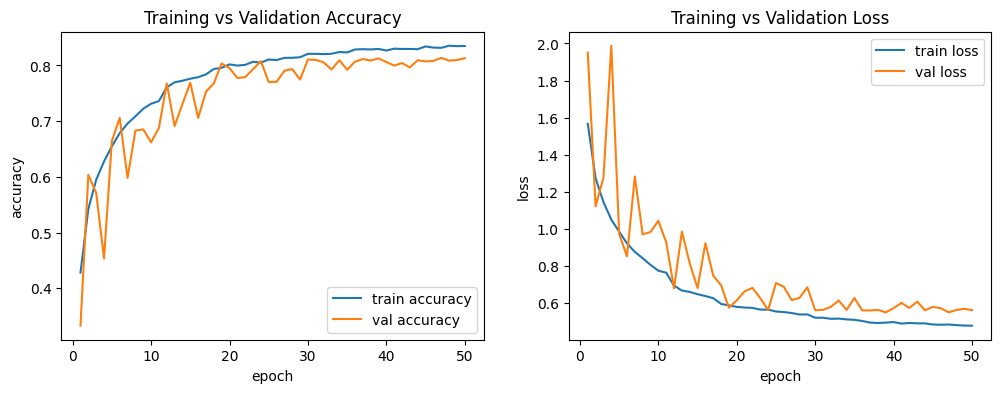

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


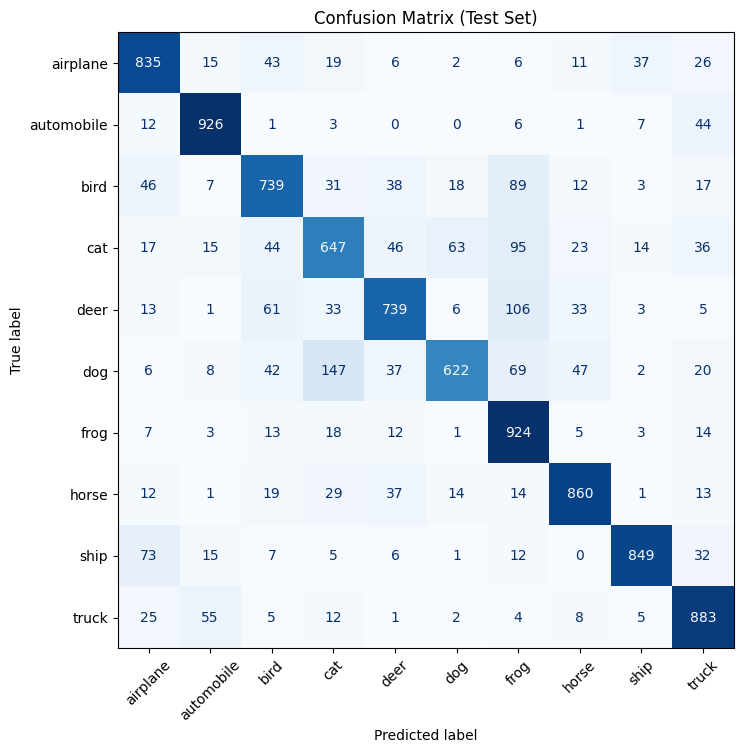

In [ ]:
checkpoint = keras.callbacks.ModelCheckpoint(
    filepath="/content/drive/MyDrive/DATAX504/best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1,
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=15,
    restore_best_weights=True,
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1,
)

history = model.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128, #try higher batch size try to reduce bouncing val_loss
    validation_data=(x_val, y_val),
    callbacks=[checkpoint,reduce_lr,early_stop],
    verbose=1,
)


acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs_range = range(1, len(acc) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, acc, label="train accuracy")
axes[0].plot(epochs_range, val_acc, label="val accuracy")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("accuracy")
axes[0].set_title("Training vs Validation Accuracy")
axes[0].legend()

axes[1].plot(epochs_range, loss, label="train loss")
axes[1].plot(epochs_range, val_loss, label="val loss")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("loss")
axes[1].set_title("Training vs Validation Loss")
axes[1].legend()

plt.show()

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(x_test).argmax(axis=1)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix (Test Set)")
plt.show()




In [ ]:
model = keras.models.load_model("/content/drive/MyDrive/DATAX504/best_model.keras")


best_val_acc = 0.8136  # from training log, epoch 47
print(f"Best validation accuracy during training: {best_val_acc*100:.2f}% (epoch 47)")

test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy % (Moodle a4_test_acc): {100 * test_acc}")

Best validation accuracy during training: 81.36% (epoch 47)
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8024 - loss: 0.5878
Test accuracy % (Moodle a4_test_acc): 80.239999294281


## 5. Filter visualisation

Pick a named conv layer (`a4_filter_layer`). Minimum expectation: plot first-layer filter weights as small images.

Optional deeper approach: gradient ascent / activation maximisation for one filter index (Ch 10 style).


(3, 3, 3, 32)
Visualisation layer (Moodle a4_filter_layer): conv2d_1


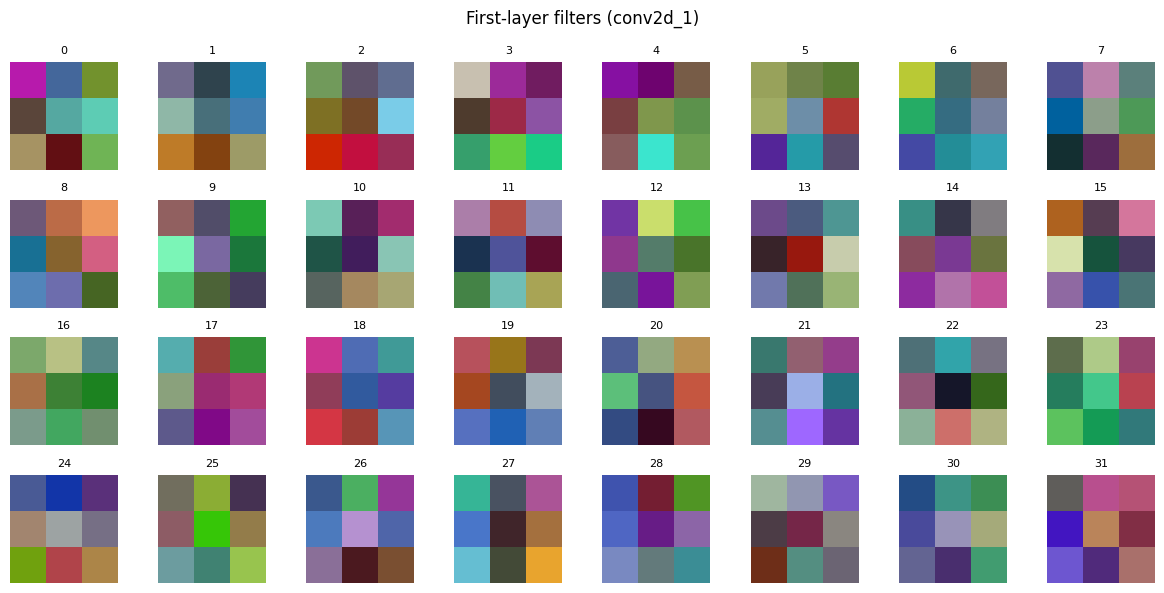

In [ ]:
VIS_LAYER = "conv2d_1"  # First layer
conv_layer = model.get_layer(VIS_LAYER)
filters = conv_layer.get_weights()[0]   # [0] pulls the array out of the list
print(filters.shape)

print(f"Visualisation layer (Moodle a4_filter_layer): {VIS_LAYER}")

import matplotlib.pyplot as plt
import numpy as np

# Normalize filter values to [0, 1] for display
f_min, f_max = filters.min(), filters.max()
filters_normalized = (filters - f_min) / (f_max - f_min)

n_filters = filters.shape[-1]  # 32
n_cols = 8
n_rows = n_filters // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 1.5, n_rows * 1.5))

for i in range(n_filters):
    ax = axes[i // n_cols, i % n_cols]
    ax.imshow(filters_normalized[:, :, :, i])
    ax.axis("off")
    ax.set_title(f"{i}", fontsize=8)

plt.suptitle(f"First-layer filters ({VIS_LAYER})")
plt.tight_layout()
plt.show()


## Filter experiments

For the first-layer filters, my first impression was that I could see no discernable corners or edges, just blocks of colour, so I decided to run some experiments to see what each filter actually responds to.

**Filter 0:** looked like a fairly natural colour mix, so I expected more "natural" looking images (frog, bird) to rank higher and less natural ones (vehicles, planes) to rank lower. The ranking below confirms this.

**Filter 16:** had a lot of green in it, so I wondered if it would mainly respond to the frog. The ranking shows the frog scoring highly, but also other images with grassy backgrounds and even a ship with a slightly grey-green background — suggesting the filter responds more broadly to green/natural tones than to the frog specifically.

The ranking is proving useful to see what filter activations are activating on which images.

In [ ]:
#rank images on how strongly they trigger for a given filter
def get_filter_activation(image, filter_index, layer_name="conv2d_1"):
    layer = model.get_layer(layer_name)
    feature_extractor = keras.Model(inputs=model.input, outputs=layer.output) #extract features from the nominated layer
    img_batch = np.expand_dims(image, axis=0) #format as a batch for keras
    activation = feature_extractor.predict(img_batch, verbose=0) #retrieve the activations from the extracted features for the layer
    return activation[0, :, :, filter_index].mean() #average activation for this one image

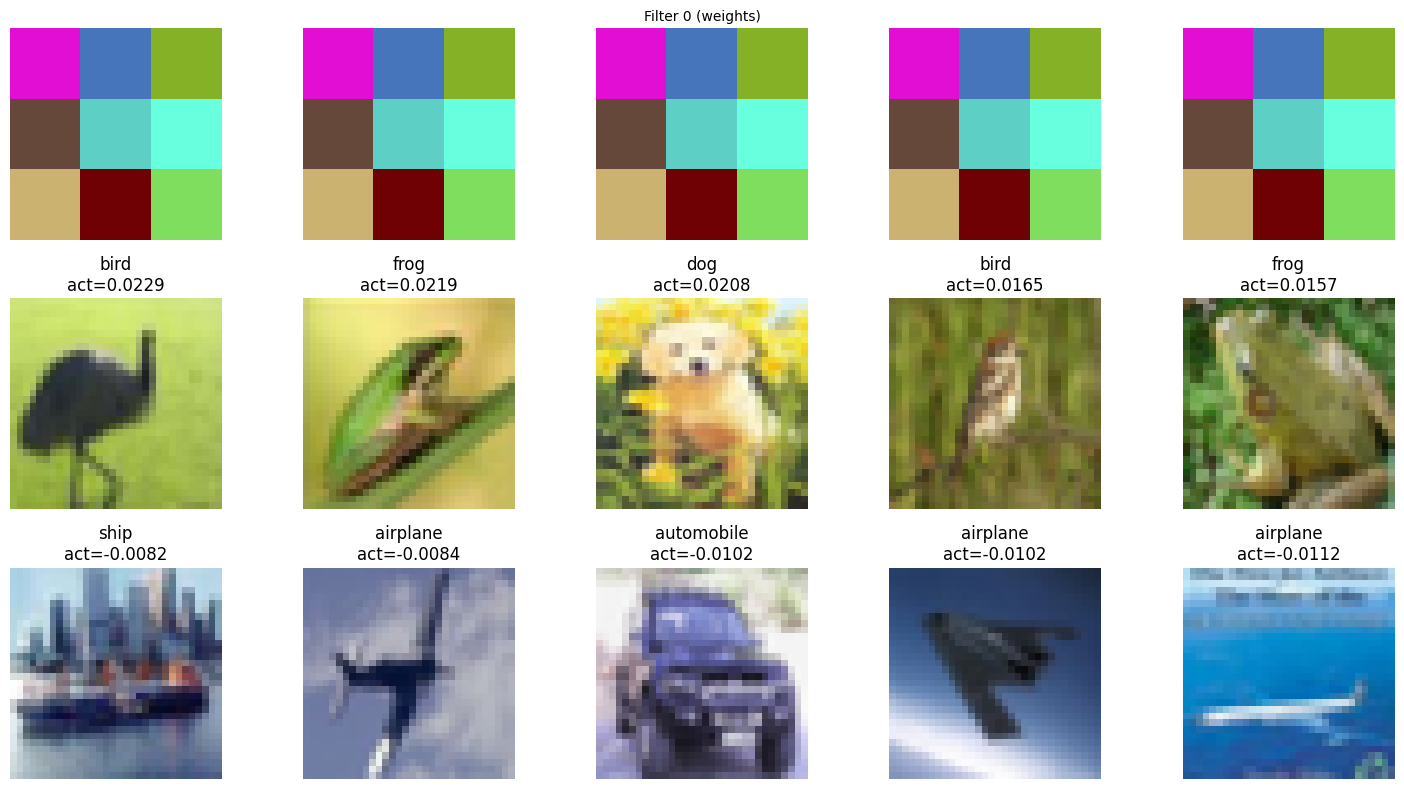

In [ ]:
results_0 = []
for i in range(200):
    act = get_filter_activation(x_test[i], filter_index=0)
    results_0.append((i, class_names[y_test[i]], act))
results_0.sort(key=lambda x: x[2], reverse=True)
top_5 = results_0[:5]
bottom_5 = results_0[-5:]


fig, axes = plt.subplots(3, 5, figsize=(15, 8))

# Row 1: the filter itself, shown once, centered (or repeated across all 5 slots for alignment)
filter_0_normalized = (filters[:, :, :, 0] - filters[:, :, :, 0].min()) / (filters[:, :, :, 0].max() - filters[:, :, :, 0].min())
for i in range(5):
    axes[0, i].imshow(filter_0_normalized)
    axes[0, i].axis("off")
axes[0, 2].set_title("Filter 0 (weights)", fontsize=10)

# Row 2: top 5 highest-activating real images
for i, (idx, label, act) in enumerate(top_5):
    axes[1, i].imshow(x_test[idx])
    axes[1, i].set_title(f"{label}\nact={act:.4f}")
    axes[1, i].axis("off")

# Row 3: bottom 5 lowest-activating real images
for i, (idx, label, act) in enumerate(bottom_5):
    axes[2, i].imshow(x_test[idx])
    axes[2, i].set_title(f"{label}\nact={act:.4f}")
    axes[2, i].axis("off")

axes[1, 0].set_ylabel("Highest\nactivation", fontsize=10)
axes[2, 0].set_ylabel("Lowest\nactivation", fontsize=10)

plt.tight_layout()
plt.show()

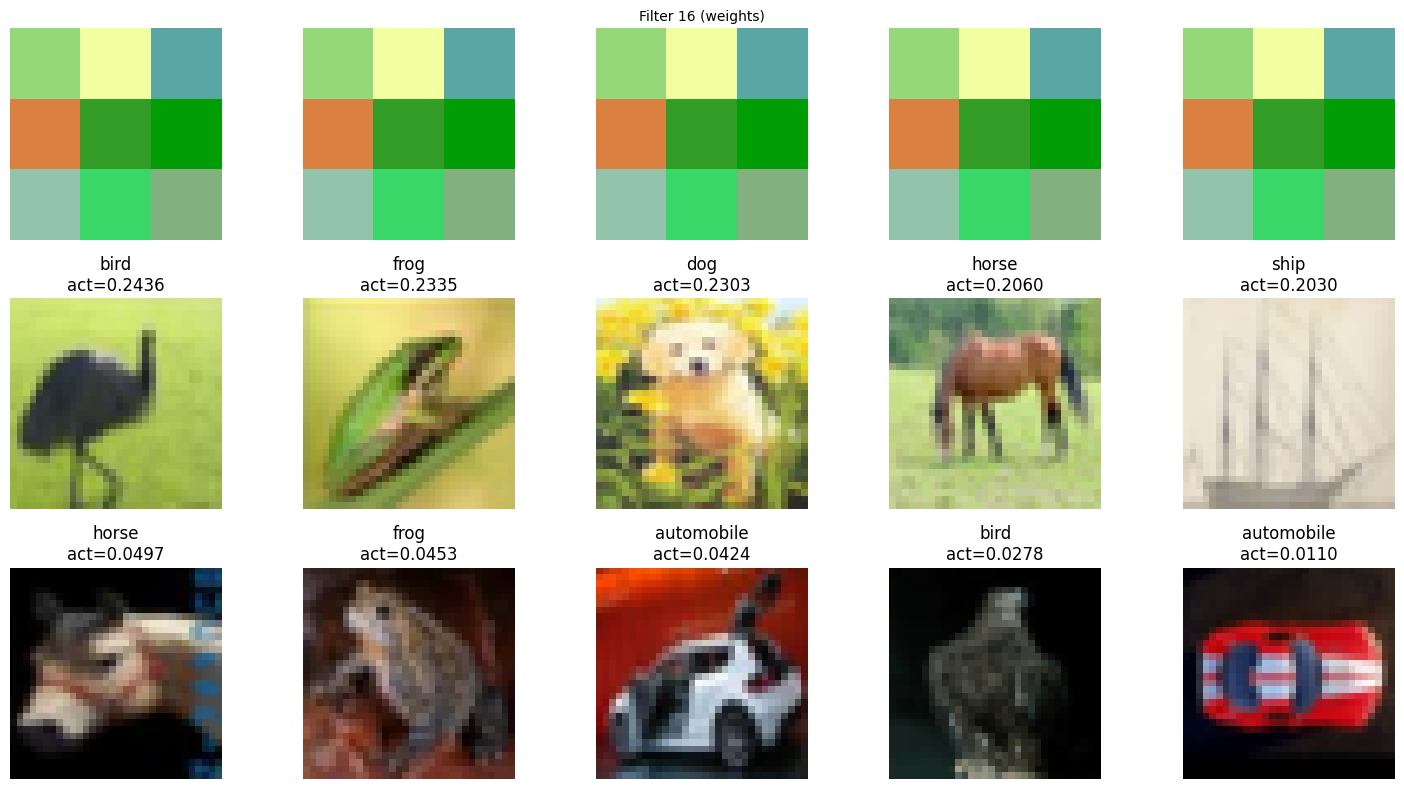

In [ ]:
results_16 = []
for i in range(200):
    act = get_filter_activation(x_test[i], filter_index=16)
    results_16.append((i, class_names[y_test[i]], act))
results_16.sort(key=lambda x: x[2], reverse=True)
top_5 = results_16[:5]
bottom_5 = results_16[-5:]

fig, axes = plt.subplots(3, 5, figsize=(15, 8))

# Row 1: the filter itself, shown once, centered (or repeated across all 5 slots for alignment)
filter_16_normalized = (filters[:, :, :, 16] - filters[:, :, :, 16].min()) / (filters[:, :, :, 16].max() - filters[:, :, :, 16].min())
for i in range(5):
    axes[0, i].imshow(filter_16_normalized)
    axes[0, i].axis("off")
axes[0, 2].set_title("Filter 16 (weights)", fontsize=10)

# Row 2: top 5 highest-activating real images
for i, (idx, label, act) in enumerate(top_5):
    axes[1, i].imshow(x_test[idx])
    axes[1, i].set_title(f"{label}\nact={act:.4f}")
    axes[1, i].axis("off")

# Row 3: bottom 5 lowest-activating real images
for i, (idx, label, act) in enumerate(bottom_5):
    axes[2, i].imshow(x_test[idx])
    axes[2, i].set_title(f"{label}\nact={act:.4f}")
    axes[2, i].axis("off")

axes[1, 0].set_ylabel("Highest\nactivation", fontsize=10)
axes[2, 0].set_ylabel("Lowest\nactivation", fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
last_conv_layer_name = "activation_5"   # not conv2d_6
last_conv_layer = model.get_layer(last_conv_layer_name)
last_conv_layer_model = keras.Model(model.input, last_conv_layer.output)

layer_names_list = [l.name for l in model.layers]
last_conv_idx = layer_names_list.index("activation_5")

classifier_input = last_conv_layer.output
x = classifier_input
for layer in model.layers[last_conv_idx + 1:]:
    x = layer(x)
classifier_model = keras.Model(classifier_input, x)

classifier_model.summary()

Model: "functional_43"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ keras_tensor_331CLONE           │ (None, 8, 8, 128)      │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,290 (5.04 KB)

 Trainable params: 1,290 (5.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def compute_gradcam(img_index):
    img_array = np.expand_dims(x_test[img_index], axis=0)

    preds = model.predict(img_array, verbose=0)
    predicted_class = np.argmax(preds[0])

    last_conv_layer_output_full = last_conv_layer_model(img_array)
    with tf.GradientTape() as tape:
        tape.watch(last_conv_layer_output_full)
        preds_inner = classifier_model(last_conv_layer_output_full)
        top_class_channel = preds_inner[:, predicted_class]
    grads = tape.gradient(top_class_channel, last_conv_layer_output_full)

    grads = grads.numpy()[0]
    conv_output = last_conv_layer_output_full.numpy()[0]

    # Pool gradients across spatial dims -> importance per channel
    pooled_grads = np.mean(grads, axis=(0, 1))

    # Weight each channel by its importance
    for i in range(pooled_grads.shape[-1]):
        conv_output[:, :, i] *= pooled_grads[i]

    heatmap = np.mean(conv_output, axis=-1)
    heatmap = np.maximum(heatmap, 0)
    heatmap = heatmap / (np.max(heatmap) + 1e-8)

    return heatmap, predicted_class

## Grad-CAM experiments

I decided to go ahead and do the Grad-CAM experiments also, as I was interested in seeing how this worked and what the heatmaps would show.

Plotting 10 images, I could see the heatmap consistently landing on the actual object being classified — the cat's body, for example. What I found interesting is that on some images it focused on a specific part rather than the whole object: the car's doors, the plane's wings, the boat's prow/bridge.

It seemed like a good way to check that the model is picking up on the correct part of the image, rather than something spurious in the background.

In [ ]:
import matplotlib.cm as cm

def show_gradcam(img_index):
    heatmap, predicted_class = compute_gradcam(img_index)

    real_img = x_test[img_index]

    # Resize heatmap (8x8) up to image size (32x32)
    heatmap_resized = tf.image.resize(heatmap[..., np.newaxis], (32, 32)).numpy().squeeze()

    fig, axes = plt.subplots(1, 3, figsize=(10, 3))
    axes[0].imshow(real_img)
    axes[0].set_title(f"Real: {class_names[y_test[img_index]]}")
    axes[0].axis("off")

    axes[1].imshow(heatmap_resized, cmap="jet")
    axes[1].set_title("Grad-CAM heatmap")
    axes[1].axis("off")

    axes[2].imshow(real_img)
    axes[2].imshow(heatmap_resized, cmap="jet", alpha=0.4)
    axes[2].set_title(f"Predicted: {class_names[predicted_class]}")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

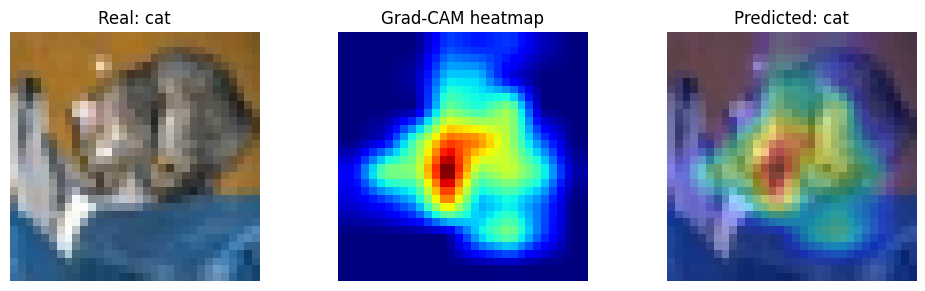

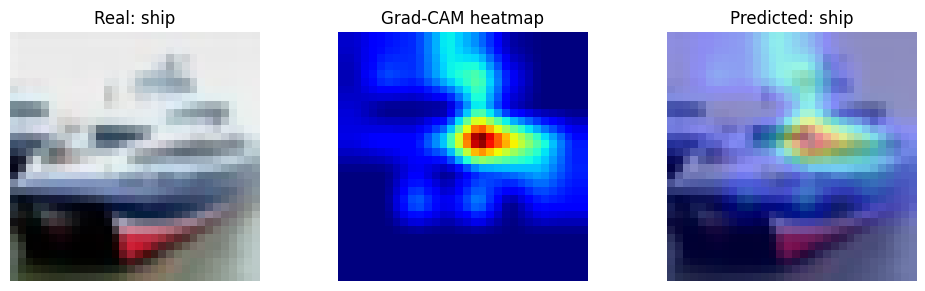

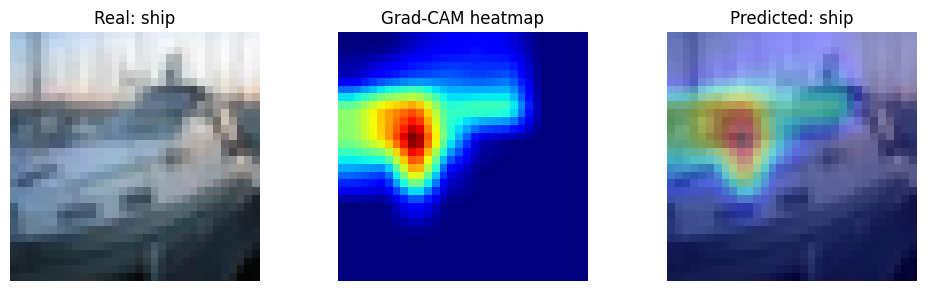

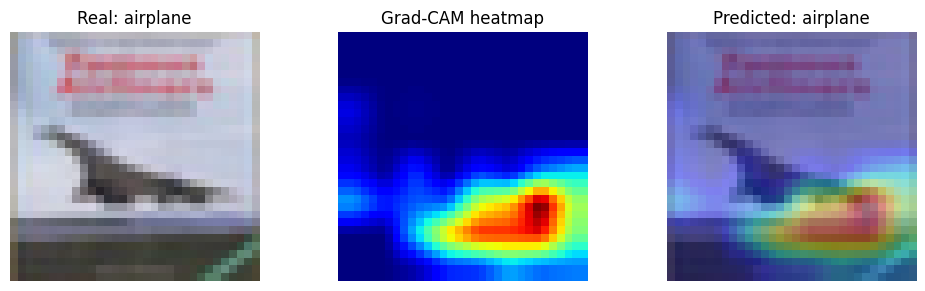

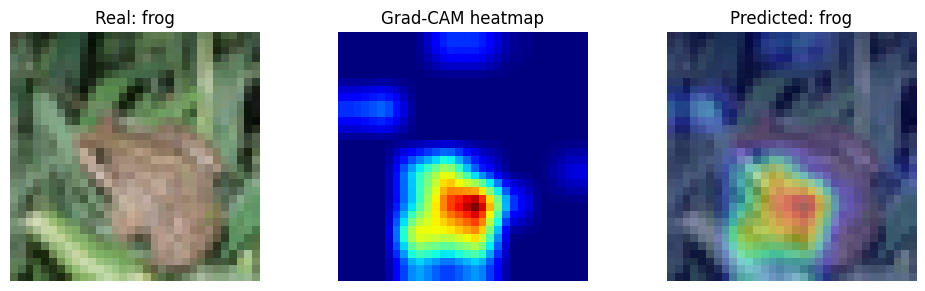

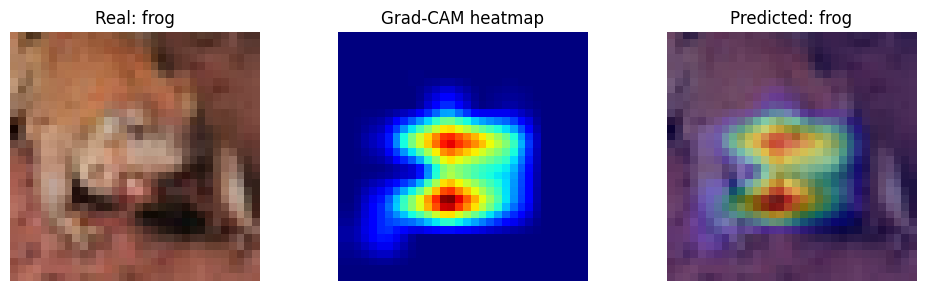

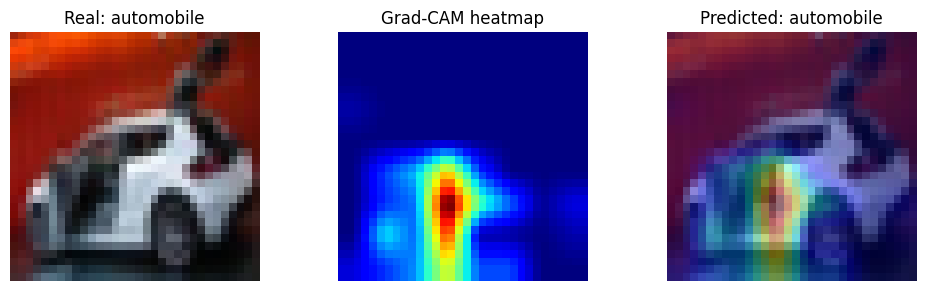

In [ ]:
for idx in [0,1, 2, 3,4,5,6]:
    show_gradcam(idx)

## 6. Interpretation (Moodle `a4_interpretation`)

Max ~200 words: what pattern does your chosen filter respond to?

Filter 0 in the first convolutional layer (conv2d_1) shows no visible edges or corners when its weights are plotted — just blocks of colour. This is likely because of the small kernel size 3*3 is very small and the original images are also quite pixellated.

Visually, filter 0's colour mix looked broadly 'natural,' so I hypothesised it would respond more strongly to natural images (frog, bird) than artificial ones (vehicles, planes). Ranking  test images confirmed this: natural-toned images consistently scored higher.

Filter 16 contained a lot of green, leading me to expect it would respond mainly to the frog class specifically. The ranking showed the frog scoring highly, but so did several other images with grassy or green-toned backgrounds, and even a ship photo with a grey-green tint — suggesting the filter responds to green/natural colouring generally, rather than being tied to any one class.

Both filters tested appear to behave more as colour detectors than edge or shape detectors, which would fit with the small 3x3 kernel size and CIFAR-10's low 32x32 resolution limiting how much detail a single filter can represent. This is based on only two filters and a small number of test images.
More images would need to be analysed to see how other filters responded.